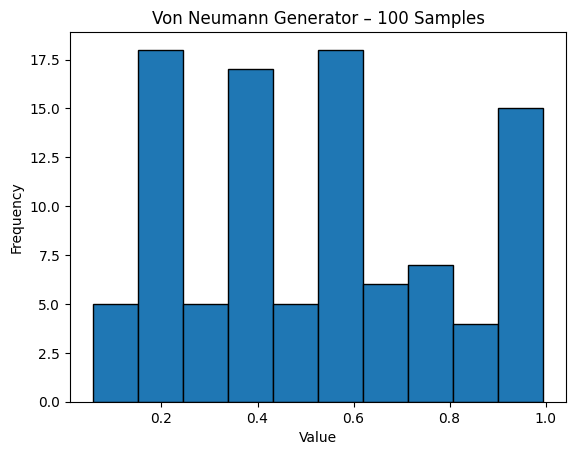

In [21]:
import numpy as np
import matplotlib.pyplot as plt
def von_neumen(seed, n=100):

    random_numbers = []
    current_value = seed

    for _ in range(n):
        squared_value = str(current_value ** 2).zfill(8)  
        middle_digits = squared_value[2:6]
        current_value = int(middle_digits)
        random_numbers.append(float(f"{current_value * 0.0001:.4f}"))

    return random_numbers

numbers = von_neumen(2481,100)
# Histogram
plt.hist(numbers, bins=10, edgecolor='black')
plt.title("Von Neumann Generator – 100 Samples")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

In [22]:
import numpy as np

def test_numbers(numbers):
    nums = np.array(numbers)

    print("** Mean Test **")
    mean = np.mean(nums)
    print("Mean =", mean)
    if abs(mean - 0.5) < 0.01:
        print("→ Passed")
    else:
        print("→ Failed")

    print("\n** Variance Test **")
    variance = np.var(nums)
    print("Variance =", variance)
    if abs(variance - 1/12) < 0.01:
        print("→ Passed")
    else:
        print("→ Failed")

test_numbers(numbers)


** Mean Test **
Mean = 0.5125540000000001
→ Failed

** Variance Test **
Variance = 0.077514587684
→ Passed


In [24]:
!pip install scipy

  Using cached scipy-1.16.3-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (62 kB)
Using cached scipy-1.16.3-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (35.7 MB)


In [25]:
from scipy.stats import chisquare

expected = np.ones(10) * (len(numbers) / 10)

observed, _ = np.histogram(numbers, bins=10)

chi_result = chisquare(observed, expected)
print("Chi-square Test Result:")
print(chi_result)


Chi-square Test Result:
Power_divergenceResult(statistic=np.float64(33.800000000000004), pvalue=np.float64(9.68258273442186e-05))


In [26]:
from scipy.stats import kstest

ks_result = kstest(numbers, 'uniform')
print("KS Test Result:")
print(ks_result)


KS Test Result:
KstestResult(statistic=np.float64(0.1079), pvalue=np.float64(0.1810476380052962), statistic_location=np.float64(0.9579), statistic_sign=np.int8(-1))
